In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [4]:
df = pd.read_csv(r'../pre-calculated_data/nanopore.csv')
df

,Sample,Total GB,N50 length,Mean Q,Site
0,CPSNJ01,45.386270,12017,15.8,NanJing_8
1,CPSNJ02,57.192760,15910,15.7,NanJing_8
2,CPSNJ03,46.479399,16752,16.0,NanJing_8
3,CPSNJ04,71.459105,17489,16.1,NanJing_8
4,CPSNJ08,48.708406,10742,15.0,NanJing_8
5,CPSNJ09,67.587256,17853,15.7,NanJing_8
6,CPSNJ10,59.134384,18330,15.7,NanJing_8
7,CPSNJ11,54.003233,19505,15.7,NanJing_8
8,CPSNJ13,47.460343,19467,15.9,NanJing_8
9,CPSNJ14,54.746032,19967,15.9,NanJing_8


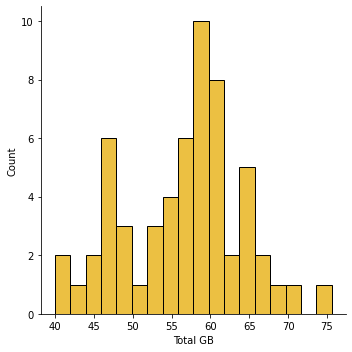

In [5]:
sns.displot(data=df,
            x='Total GB',
            color='#e6ab02',binwidth=2)

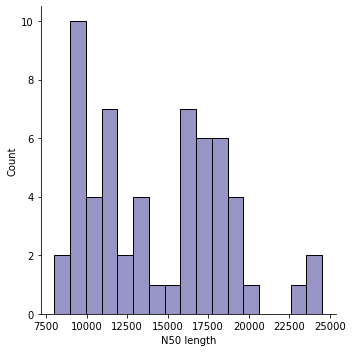

In [6]:
sns.displot(data=df,
            x='N50 length',
            color='#7570b3',binwidth=1000)

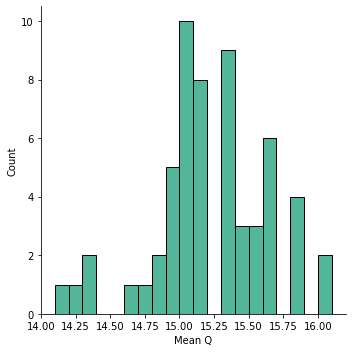

In [7]:
sns.displot(data=df,
            x='Mean Q',
            color='#1b9e77',binwidth=0.1)

In [8]:
df = pd.read_csv('../pre-calculated_data/alpha_diversity.csv', index_col=0)
df

,chao1,simpson,shannon,Site,Ecosystem
sample,,,,,
SRR25158350,2815.955027,0.971360,6.893876,SMAG,Wetland
SRR25158304,2518.101709,0.971311,6.556217,SMAG,Bare Land
SRR25158536,3913.855805,0.971324,7.321940,SMAG,Forest
SRR25158444,4700.153402,0.971383,7.310066,SMAG,Agricultural Land
SRR25158393,4808.474763,0.971378,7.424590,SMAG,Agricultural Land
...,...,...,...,...,...
D044_350,1419.713475,0.971202,3.251397,Dog,Canine Gut
D032_350,753.296915,0.971105,2.611935,Dog,Canine Gut
D036_350,1097.076559,0.971146,3.510075,Dog,Canine Gut


In [9]:
df["Type"] = df['Ecosystem']+" - "+df['Site']
custom_dict =  {"Urban - Nanjing":0, "Urban - Shanghai":1, 'Bare Land - SMAG':2, 'Wetland - SMAG':3,
                'Agricultural Land - SMAG':4, 'Grassland - SMAG':5, 'Forest - SMAG':6, "Canine Gut - Dog":7}
df = df.sort_values(by=['Type'], key=lambda x: x.map(custom_dict))
df

,chao1,simpson,shannon,Site,Ecosystem,Type
sample,,,,,,
CPSNJ19_350,4010.306504,0.971357,7.428859,Nanjing,Urban,Urban - Nanjing
CPSNJ09_350,3372.492190,0.971301,7.242591,Nanjing,Urban,Urban - Nanjing
CPSNJ11_350,3741.898495,0.971339,7.363220,Nanjing,Urban,Urban - Nanjing
CPSNJ08_350,6044.157190,0.971377,7.731424,Nanjing,Urban,Urban - Nanjing
SNJ09_350,4899.927311,0.971338,7.490018,Nanjing,Urban,Urban - Nanjing
...,...,...,...,...,...,...
D004_350,2485.869093,0.971221,3.842872,Dog,Canine Gut,Canine Gut - Dog
D033_350,1015.213640,0.970938,2.394294,Dog,Canine Gut,Canine Gut - Dog
D045_350,977.714580,0.971061,2.670187,Dog,Canine Gut,Canine Gut - Dog


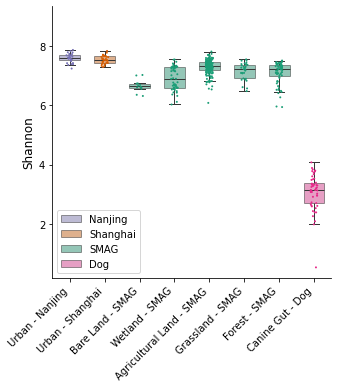

In [36]:
custom_palette = {
    'Nanjing': '#7570b3',
    'Shanghai': '#d95f02',
    'SMAG': '#1b9e77',
    'Dog': '#e7298a',
}

fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(data=df, x="Type", y="shannon", color='white', hue="Site", 
             palette=custom_palette,boxprops=dict(alpha=0.5),
            showfliers=False, ax=ax, width=0.6)

sns.stripplot(data=df, x="Type", y="shannon", hue="Site",
             palette=custom_palette, ax=ax,size=2, jitter=True,legend=False)

y_max = df['shannon'].max()
y_min = df['shannon'].min()
vertical_offset = 0.1 * (y_max - y_min)
current_level = 1  

ax.set_ylim(top=y_max + vertical_offset * (current_level + 1))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Shannon', fontsize=12)
ax.set_xlabel('')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[0:4], labels=labels[0:4], loc="lower left")
plt.xticks(rotation=45, ha='right')

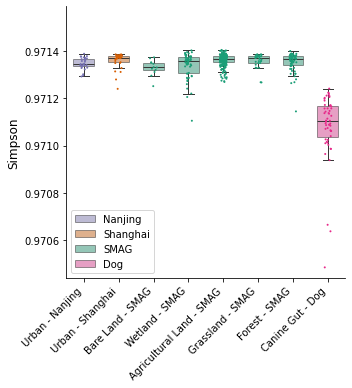

In [35]:
custom_palette = {
    'Nanjing': '#7570b3',
    'Shanghai': '#d95f02',
    'SMAG': '#1b9e77',
    'Dog': '#e7298a',
}

fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(data=df, x="Type", y="simpson", color='white', hue="Site", 
             palette=custom_palette,boxprops=dict(alpha=0.5),
            showfliers=False, ax=ax, width=0.6, order=["Urban - Nanjing", "Urban - Shanghai", 'Bare Land - SMAG', 'Wetland - SMAG',
                                                       'Agricultural Land - SMAG', 'Grassland - SMAG', 'Forest - SMAG', "Canine Gut - Dog"])

sns.stripplot(data=df, x="Type", y="simpson", hue="Site",
             palette=custom_palette, ax=ax,size=2, jitter=True, order=["Urban - Nanjing", "Urban - Shanghai", 'Bare Land - SMAG', 'Wetland - SMAG',
                                                       'Agricultural Land - SMAG', 'Grassland - SMAG', 'Forest - SMAG', "Canine Gut - Dog"],legend=False)

tukey = pairwise_tukeyhsd(endog=df['simpson'], groups=df['Type'], alpha=0.05)
summary = tukey.summary()

significant_pairs = []
for i in range(1, len(summary.data)):
    row = summary.data[i]
    if float(row[3]) < 0.05:
        if "Canine Gut - Dog" not in [row[0], row[1]]:
            group1 = row[0]
            group2 = row[1]
            p_val = float(row[3])
            significant_pairs.append( (group1, group2, p_val) )

group_order = df['Type'].unique()
x_positions = {group: idx for idx, group in enumerate(group_order)}

y_max = df['simpson'].max()
y_min = df['simpson'].min()
vertical_offset = 0.1 * (y_max - y_min)
current_level = 1  
line_props = {'color': 'black', 'linewidth': 1, 'transform': ax.transData}
for pair in significant_pairs:
    group1, group2, p_val = pair
    x1 = x_positions[group1]
    x2 = x_positions[group2]
    if p_val < 0.001:
        symbol = '***'
    elif p_val < 0.01:
        symbol = '**'
    elif p_val < 0.05:
        symbol = '*'
    else:
        continue
    y_top = y_max + (vertical_offset * current_level)
    y_line = y_top - 0.1 * vertical_offset
    ax.plot([x1, x1, x2, x2], 
            [y_line, y_top, y_top, y_line], **line_props)
    ax.text((x1+x2)/2, y_top, symbol, 
            ha='center', va='bottom', 
            fontsize=12, color='black')
    current_level += 1 

ax.set_ylim(top=y_max + vertical_offset * (current_level + 1))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Simpson', fontsize=12)
ax.set_xlabel('')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[0:4], labels=labels[0:4], loc="lower left")
plt.xticks(rotation=45, ha='right')